In [1]:
import sklearn.metrics as metrics
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from keras.utils import to_categorical
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


C:\Users\zxzx2\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


In [2]:
df = pd.read_csv("epc_best20.csv")

In [3]:
# Split data into features and labels
X = df.drop("Current energy efficiency rating band", axis=1)
y = df["Current energy efficiency rating band"]
encoder = LabelEncoder()
y= encoder.fit_transform(y)

# One-hot encode labels
y = to_categorical(y, num_classes=7)

In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [5]:
# Define which columns are categorical and which are numerical
categorical_cols = ["Part 1 Construction Age Band", "Mechanical Ventilation", "Tenure", "Transaction Type",
                   "wall_insulation", "roof_insulation", "wall_type", "roof_type", "floor_type",
                   "windows_glazing", "low_lighting"]
numerical_cols = ["Total floor area (m²)", "Total current energy costs over 3 years (£)",
                  "Current hot water costs over 3 years (£)", "Part 1 Floor 0 Room Height",
                  "Low Energy Lighting %", "insulated_wall", "MMH_mains gas", "MHCS_programmer",
                  "SH_room heaters"]

In [6]:
# Create ColumnTransformer to handle different data types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)])

In [7]:
# Fit and transform the data using the ColumnTransformer
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [8]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.5))  # Adding dropout to prevent overfitting
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  # Adding dropout to prevent overfitting
model.add(Dense(7, activation='sigmoid'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
history = model.fit(X_train, y_train,validation_data = (X_test,y_test), epochs=20, batch_size=32)

Epoch 1/20


C:\Users\zxzx2\Anaconda3\lib\site-packages\tensorflow\python\framework\indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential/dense/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential/dense/embedding_lookup_sparse/Reshape:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/sequential/dense/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)


1193/1193 [==============================] - 6s 4ms/step - loss: 0.9138 - accuracy: 0.6457 - val_loss: 0.5965 - val_accuracy: 0.7661
Epoch 2/20
1193/1193 [==============================] - 6s 5ms/step - loss: 0.6688 - accuracy: 0.7401 - val_loss: 0.5162 - val_accuracy: 0.7993
Epoch 3/20
1193/1193 [==============================] - 5s 4ms/step - loss: 0.5950 - accuracy: 0.7711 - val_loss: 0.4786 - val_accuracy: 0.8108
Epoch 4/20
1193/1193 [==============================] - 6s 5ms/step - loss: 0.5569 - accuracy: 0.7870 - val_loss: 0.4441 - val_accuracy: 0.8290
Epoch 5/20
1193/1193 [==============================] - 5s 4ms/step - loss: 0.5243 - accuracy: 0.8011 - val_loss: 0.4247 - val_accuracy: 0.8347
Epoch 6/20
1193/1193 [==============================] - 5s 4ms/step - loss: 0.5076 - accuracy: 0.8076 - val_loss: 0.4182 - val_accuracy: 0.8372
Epoch 7/20
1193/1193 [==============================] - 5s 4ms/step - loss: 0.4977 - accuracy: 0.8129 - val_loss: 0.4145 - val_accuracy: 0.8353
Epo

In [10]:
# Evaluate model
score = model.evaluate(X_test, y_test)
print("Test loss: ", score[0])
print("Test accuracy: ", score[1])

511/511 [==============================] - 1s 2ms/step - loss: 0.3737 - accuracy: 0.8486
Test loss:  0.37367308139801025
Test accuracy:  0.8486145734786987


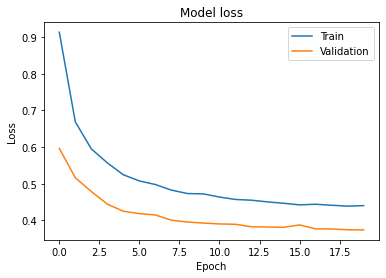

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

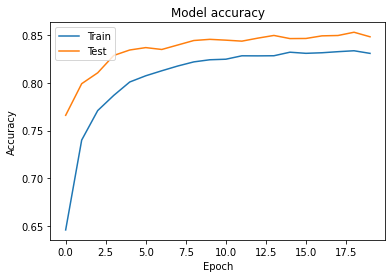

In [12]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


511/511 [==============================] - 1s 2ms/step
Average AUC: 0.9436401181524269


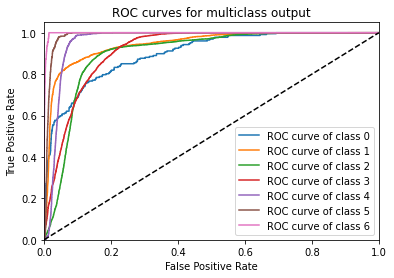

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Compute the predicted probabilities for each class
y_pred_proba = model.predict(X_test)

# Compute the average AUC score across all classes
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print('Average AUC:', auc)

# Compute the FPR and TPR for each class
fpr = dict()
tpr = dict()
for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_proba[:, i])

# Plot the ROC curve for each class
plt.figure()
for i in range(7):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {}'.format(i))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for multiclass output')
plt.legend(loc="lower right")
plt.show()





In [14]:
# Make predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)

#convert one hot encoded y_test to numerical format
y_test = y_test.argmax(axis=1)

# Evaluate model
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall: ", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score: ", f1_score(y_test, y_pred, average='weighted'))

511/511 [==============================] - 1s 3ms/step
Accuracy:  0.8475747752156095
Precision:  0.8429127335750003
Recall:  0.8475747752156095
F1 Score:  0.8405946068081761


In [15]:
    import numpy as np
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) 
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"\nr2: {rmse}") ##print mean square error and r2
    print(f"\nRMSE: {rmse}")


r2: 0.4150953100912154

RMSE: 0.4150953100912154


In [16]:
def plot_conf_mat(y_test, y_pred):
    '''prints the confusion matrix'''
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5,5))
    ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='small')

    plt.xlabel('Predictions', fontsize=10)
    plt.ylabel('Actuals', fontsize=10)
    plt.title('Confusion Matrix', fontsize=10)
    plt.show()
    return

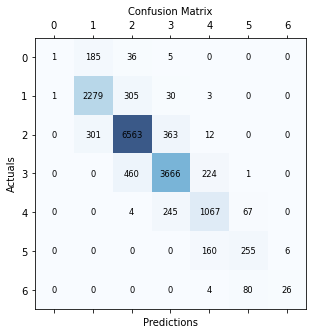

In [17]:
plot_conf_mat(y_test, y_pred)